In [28]:
from pymongo import MongoClient
import pandas as pd

try: 
    client = MongoClient("localhost", 27017)
    print("Connected successfully!!!") 
except:
    print("Could not connect to MongoDB")

db = client["flask_db"]
activity = db.activity



Connected successfully!!!


In [29]:
query = {"project": "656fadd102ae94a7686aae62", "editingLines": {"$exists": True, "$ne": None}}

cursor = activity.find(query)

df = pd.DataFrame(list(cursor))
#df = df.astype({"text": str, "state": str, "line": str, "username": str, "project": str, "file": str, "message": str})

col_names = df.columns.tolist()
dtypes = df.dtypes
df.head()

,_id,timestamp,text,revision,state,line,username,project,file,editingLines,message,changes,clipboard,cb
0,65708e17ea0333c46f1ce0d5,1701875222539,,"[[-1, % This must be in the first 5 lines to t...",Typing,1,das00015@umn.edu,656fadd102ae94a7686aae62,introduction.tex,[1],Typing,"[(1,0), % This must be in the first 5 lines to...",NaN,NaN
1,65710cb4ea0333c46f1ce11f,1701907635170,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \n---added]",NaN,NaN
2,65710cbfea0333c46f1ce120,1701907646740,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL }---added]",NaN,NaN
3,65710cc0ea0333c46f1ce121,1701907647197,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL }->\karin{DebL}]",NaN,NaN
4,65710cc0ea0333c46f1ce122,1701907648145,%I change the title to be more NLP-ish - Shirl...,"[[0, %I change the title to be more NLP-ish - ...",Typing,139,karin,656fadd102ae94a7686aae62,acl_latex.tex,"[103, 104, 105, 106, 107, 108, 109, 110, 111, ...",Typing,"[(139,0), \karin{DebL}->\karin{Deb: ]",NaN,NaN


In [30]:
print("column names", col_names)
print("num rows", len(df))

print("average len", df["editingLines"].apply(len).mean())
print("median len", df["editingLines"].apply(len).median())
print("mode len", df["editingLines"].apply(len).mode().tolist())

column names ['_id', 'timestamp', 'text', 'revision', 'state', 'line', 'username', 'project', 'file', 'editingLines', 'message', 'changes', 'clipboard', 'cb']
num rows 30006
average len 40.23598613610611
median len 37.0
mode len [35]


In [31]:
print("unique files in project", df["file"].unique())

unique files in project ['introduction.tex' 'acl_latex.tex' 'images' 'latex' 'simulation.tex'
 'instruction.tex' 'tasklabels.tex' 'freetext.tex' 'preference.tex'
 'acl_natbib.bst' 'bibtex' 'human_raters.bib' 'free_form_text.bib'
 'instructions.bib' 'overview.tex' 'pref_eval.bib' 'discussion.tex'
 'pref_eval' 'human_raters' 'simulation' 'wass_trend.pdf'
 'data_explanation_appendix.tex' 'exp_results.tex' 'main.tex'
 'instructions' 'simulation.bib' 'appendix.tex' 'icons'
 'freetext_appendix.tex' 'data_types.tex' 'exp_results_2.tex' 'free_text'
 'methods.tex' 'contributions.tex' 'custom.bib']


In [32]:
df1 = df["username"].value_counts().sort_values()
df["line_counts"] = df["editingLines"].apply(len)

df2 = df.groupby(["username"])["line_counts"].sum().sort_values()
print(df.head())

print(df1)
print(df2)


                        _id      timestamp  \
0  65708e17ea0333c46f1ce0d5  1701875222539   
1  65710cb4ea0333c46f1ce11f  1701907635170   
2  65710cbfea0333c46f1ce120  1701907646740   
3  65710cc0ea0333c46f1ce121  1701907647197   
4  65710cc0ea0333c46f1ce122  1701907648145   

                                                text  \
0                                                      
1  %I change the title to be more NLP-ish - Shirl...   
2  %I change the title to be more NLP-ish - Shirl...   
3  %I change the title to be more NLP-ish - Shirl...   
4  %I change the title to be more NLP-ish - Shirl...   

                                            revision   state line  \
0  [[-1, % This must be in the first 5 lines to t...  Typing    1   
1  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
2  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
3  [[0, %I change the title to be more NLP-ish - ...  Typing  139   
4  [[0, %I change the title to be more NL

['das00015@umn.edu' 'karin' 'lee03533@umn.edu' 'debaratidas'
 'hu000562@umn.edu' 'mart5877@umn.edu' 'Zae' 'owan0002@umn.edu'
 'hayat023@umn.edu']


/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_18250/1378739903.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")
/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_18250/1378739903.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=40, ha="right")


[Text(0, 0, 'hayat023@umn.edu'),
 Text(1, 0, 'hu000562@umn.edu'),
 Text(2, 0, 'mart5877@umn.edu'),
 Text(3, 0, 'owan0002@umn.edu'),
 Text(4, 0, 'Zae'),
 Text(5, 0, 'lee03533@umn.edu'),
 Text(6, 0, 'das00015@umn.edu'),
 Text(7, 0, 'debaratidas'),
 Text(8, 0, 'karin')]

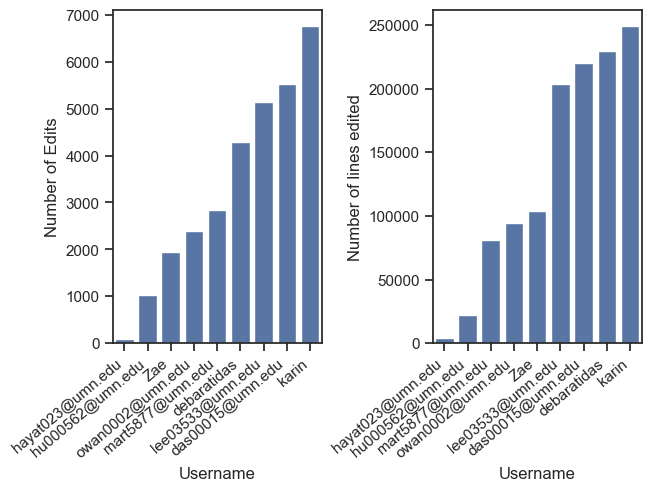

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

print(df["username"].unique())

fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout = True) 

ax1 = sns.barplot(df1, ax=ax1)
ax1.set(xlabel='Username', ylabel='Number of Edits')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")


ax2 = sns.barplot(df2, ax=ax2)
ax2.set(xlabel="Username", ylabel="Number of lines edited")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=40, ha="right")




/var/folders/b4/tsyrjt4j47766fqchqsyvycm0000gn/T/ipykernel_18250/1102478508.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


[Text(-5000.0, 0, '−5000'),
 Text(0.0, 0, '0'),
 Text(5000.0, 0, '5000'),
 Text(10000.0, 0, '10000'),
 Text(15000.0, 0, '15000'),
 Text(20000.0, 0, '20000'),
 Text(25000.0, 0, '25000'),
 Text(30000.0, 0, '30000'),
 Text(35000.0, 0, '35000')]

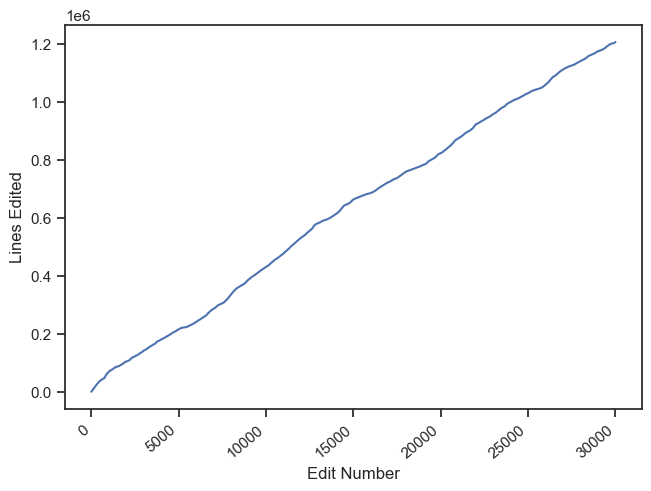

In [36]:
df["edits"] = df["editingLines"].apply(len)
df["cum_edits"] = df["edits"].cumsum()

fig, ax = plt.subplots(1, 1, constrained_layout = True) 

ax = sns.lineplot(df["cum_edits"], ax=ax)
ax.set(xlabel='Edit Number', ylabel='Lines Edited')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")


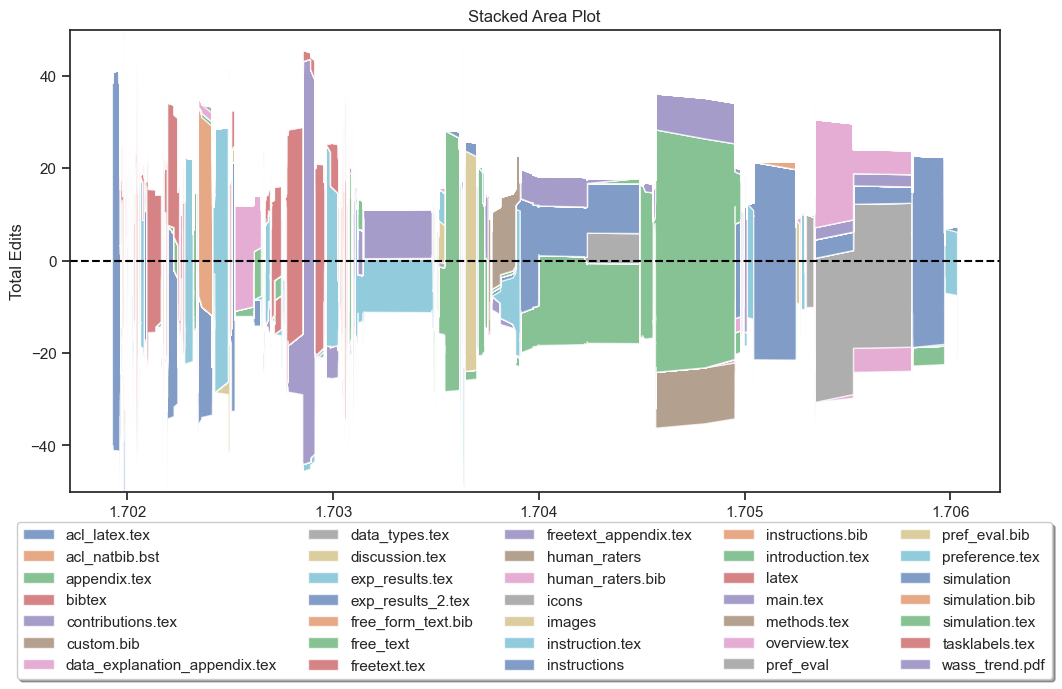

In [66]:


pivot_df = pd.pivot_table(df, values="edits", index="timestamp", columns="file", aggfunc="sum", fill_value=0)

window_size = 30  # Adjust the window size as needed
pivot_df = pivot_df.rolling(window=window_size).mean()

fig, ax = plt.subplots(figsize=(12, 6)) 

ax.stackplot(pivot_df.index, pivot_df.values.T, labels=pivot_df.columns, alpha=0.7, baseline="sym")

# Add labels and title
ax.set_xlabel('Timestamp')
ax.set_ylabel('Total Edits')
ax.set_title('Stacked Area Plot')
ax.set_ylim((-50,50))
ax.axhline(0, color="black", ls="--");
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=5)

